In [1]:
import pandas as pd
import numpy as np
import gzip
from io import StringIO


In [2]:
def load_geo_series_matrix(path):
    with gzip.open(path, 'rt') as f:
        lines = f.readlines()

    start, end = None, None
    for i, line in enumerate(lines):
        if line.startswith("!series_matrix_table_begin"):
            start = i + 1
        elif line.startswith("!series_matrix_table_end"):
            end = i
            break

    if start is None or end is None:
        raise ValueError("Series matrix table not found")

    data = ''.join(lines[start:end])
    df = pd.read_csv(StringIO(data), sep="\t", index_col=0)
    return df


In [3]:
path = "/workspaces/Reasearch_Genomic/GSE99039_series_matrix.txt.gz.1"

df = load_geo_series_matrix(path)
print("Original shape:", df.shape)


Original shape: (54675, 558)


In [4]:
X = df.T
print("After transpose:", X.shape)


After transpose: (558, 54675)


In [5]:
y = np.zeros(X.shape[0])
y[: X.shape[0] // 2] = 1


In [6]:
X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(0)

print(X.dtypes.unique())


[dtype('float64')]


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [8]:
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel

svc = LinearSVC(
    penalty="l1",
    dual=False,
    max_iter=2000
)

selector = SelectFromModel(svc, max_features=32)
selector.fit(X_scaled, y)

selected_mask = selector.get_support()
selected_genes = X.columns[selected_mask]

print("Selected genes:", len(selected_genes))



Selected genes: 32


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [9]:
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel
import pandas as pd
import numpy as np

svc = LinearSVC(
    penalty="l1",
    dual=False,
    max_iter=2000
)

selector = SelectFromModel(svc, max_features=32)
selector.fit(X_scaled, y)

selected_mask = selector.get_support()
selected_genes = X.columns[selected_mask]

top_32 = pd.DataFrame({
    "Gene": selected_genes
})

top_32



/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,Gene
0,1554241_at
1,1555237_at
2,1555282_a_at
3,1555821_a_at
4,1556009_at
5,1558919_a_at
6,1563845_at
7,1567628_at
8,1569353_at
9,203781_at


In [10]:
top_32.to_csv("GSE99039_Top32_LASSO.csv", index=False)


In [11]:
selected_genes = top_32["Gene"].values
X_lasso = X[selected_genes]


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_lasso,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


2026-02-12 17:04:48.349623: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-12 17:05:03.166600: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-12 17:05:12.268164: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [15]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-12 17:05:14.464364: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,225 (16.50 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,089 (4.25 KB)

 Trainable params: 1,089 (4.25 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1
)


Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5247 - loss: 0.8557 - val_accuracy: 0.5982 - val_loss: 0.7171
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6570 - loss: 0.6168 - val_accuracy: 0.6875 - val_loss: 0.5728
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7466 - loss: 0.4850 - val_accuracy: 0.7768 - val_loss: 0.4781
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8161 - loss: 0.4213 - val_accuracy: 0.8750 - val_loss: 0.4130
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8767 - loss: 0.3548 - val_accuracy: 0.8929 - val_loss: 0.3634
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9148 - loss: 0.2983 - val_accuracy: 0.9018 - val_loss: 0.3270
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9148 - loss: 0.2748 - val_accuracy: 0.9018 - val_loss: 0.2943
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9372 - loss: 0.2431 - val_accuracy: 0.8929 - val_loss:

In [22]:
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Loss: {loss:.4f}")


Validation Accuracy: 0.9464
Validation Loss: 0.1749


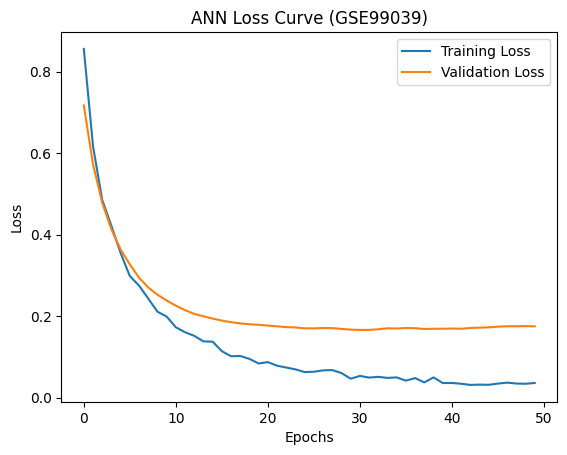

In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("ANN Loss Curve (GSE99039)")
plt.legend()
plt.show()


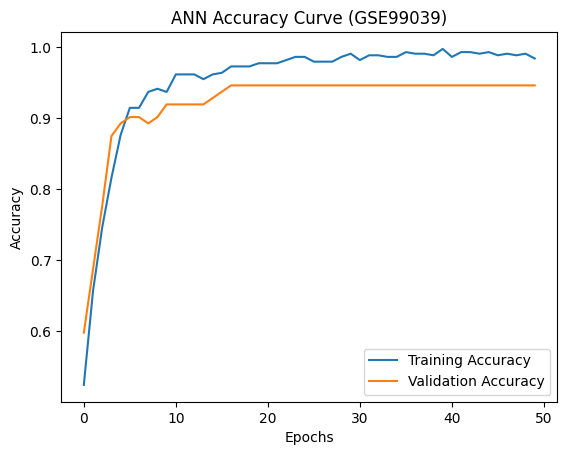

In [24]:
plt.figure()
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("ANN Accuracy Curve (GSE99039)")
plt.legend()
plt.show()


In [25]:
from sklearn.metrics import f1_score

# Make predictions on validation set
y_pred = (model.predict(X_val) > 0.5).astype(int).flatten()

# Calculate F1 score
f1 = f1_score(y_val, y_pred)

print(f"F1 Score: {f1:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
F1 Score: 0.9474


In [26]:
from sklearn.metrics import recall_score

recall = recall_score(y_val, y_pred)
print(f"Recall Score: {recall:.4f}")

Recall Score: 0.9643


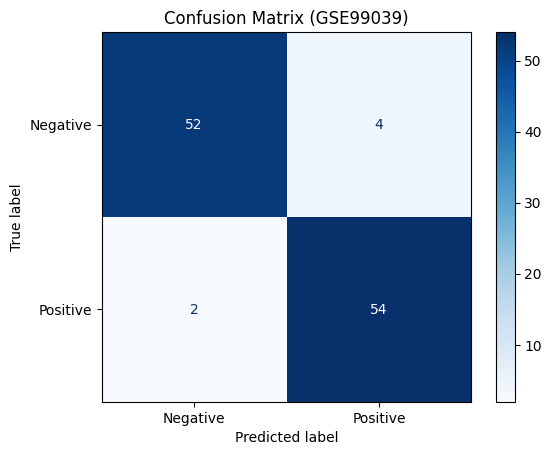

Confusion Matrix:
[[52  4]
 [ 2 54]]

True Negatives: 52
False Positives: 4
False Negatives: 2
True Positives: 54


In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (GSE99039)")
plt.show()

# Print confusion matrix values
print("Confusion Matrix:")
print(cm)
print(f"\nTrue Negatives: {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives: {cm[1, 1]}")

In [28]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_model_GSE99039.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Retrain model with callbacks
model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

print(f"Best validation loss: {min(history.history['val_loss']):.4f}")

Epoch 1/50


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 1/28 ━━━━━━━━━━━━━━━━━━━━ 22s 824ms/step - accuracy: 0.5000 - loss: 0.7517
Epoch 1: val_loss improved from None to 0.55133, saving model to best_model_GSE99039.h5



Epoch 1: finished saving model to best_model_GSE99039.h5
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6368 - loss: 0.6578 - val_accuracy: 0.7589 - val_loss: 0.5513
Epoch 2/50
 1/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6875 - loss: 0.5096
Epoch 2: val_loss improved from 0.55133 to 0.46046, saving model to best_model_GSE99039.h5



Epoch 2: finished saving model to best_model_GSE99039.h5
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7534 - loss: 0.5092 - val_accuracy: 0.8125 - val_loss: 0.4605
Epoch 3/50
 1/28 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7500 - loss: 0.5764
Epoch 3: val_loss improved from 0.46046 to 0.39657, saving model to best_model_GSE99039.h5


...


Epoch 23: finished saving model to best_model_GSE99039.h5
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9843 - loss: 0.0686 - val_accuracy: 0.9554 - val_loss: 0.1494
Epoch 24/50
 1/28 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 1.0000 - loss: 0.0254
Epoch 24: val_loss improved from 0.14937 to 0.14839, saving model to best_model_GSE99039.h5



Epoch 24: finished saving model to best_model_GSE99039.h5
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9821 - loss: 0.0615 - val_accuracy: 0.9554 - val_loss: 0.1484
Epoch 25/50
23/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.0566 
Epoch 25: val_loss improved from 0.14839 to 0.14761, saving model to best_model_GSE99039.h5



Epoch 25: finished saving model to best_model_GSE99039.h5
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9776 - loss: 0.0621 - val_accuracy: 0.9554 - val_loss: 0.1476
Epoch 26/50
 1/28 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.0165
Epoch 26: val_loss improved from 0.14761 to 0.14629, saving model to best_model_GSE99039.h5



Epoch 26: finished saving model to best_model_GSE99039.h5
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9865 - loss: 0.0586 - val_accuracy: 0.9643 - val_loss: 0.1463
Epoch 27/50
 1/28 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.0625
Epoch 27: val_loss did not improve from 0.14629
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9821 - loss: 0.0594 - val_accuracy: 0.9554 - val_loss: 0.1470
Epoch 28/50
 1/28 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.0705
Epoch 28: val_loss did not improve from 0.14629
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9843 - loss: 0.0572 - val_accuracy: 0.9464 - val_loss: 0.1466
Epoch 29/50
 1/28 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0626
Epoch 29: val_loss improved from 0.14629 to 0.14615, saving model to best_model_GSE99039.h5



Epoch 29: finished saving model to best_model_GSE99039.h5
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9865 - loss: 0.0532 - val_accuracy: 0.9554 - val_loss: 0.1462
Epoch 30/50
 1/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0741
Epoch 30: val_loss did not improve from 0.14615
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9910 - loss: 0.0506 - val_accuracy: 0.9464 - val_loss: 0.1471
Epoch 31/50
 1/28 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.0130
Epoch 31: val_loss did not improve from 0.14615
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9888 - loss: 0.0474 - val_accuracy: 0.9554 - val_loss: 0.1469
Epoch 32/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9746 - loss: 0.0682 
Epoch 32: val_loss did not improve from 0.14615
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9776 - loss: 0.0623 - val_accuracy: 0.9464 - val_loss: 0.1508
Epoch 33/50
 1/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 